# **Project Name**    -  FED-EX



##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual
#####   Name         - Shaik Mohammed Ashwaqullah


# **Project Summary -**

This project focuses on performing Exploratory Data Analysis on a supply chain delivery dataset to understand shipment patterns, cost distribution, and logistics performance. The dataset includes information such as shipment mode, country, vendor, product group, quantity, unit price, weight, and freight cost.

Through data cleaning, preprocessing, and visualization techniques, the analysis explores how different variables are distributed and how they relate to each other. Key insights reveal that most shipments are small to moderate in size, while freight cost is strongly influenced by shipment weight and quantity. Additionally, certain shipment modes, vendors, and regions dominate the supply chain operations.

The findings from this analysis can help businesses optimize logistics planning, reduce transportation costs, and improve overall supply chain efficiency. This project demonstrates how data-driven insights can support better decision-making in real-world logistics scenarios.


# **GitHub Link -**

https://github.com/ashwaaaaq



# **Problem Statement**


The objective of this project is to perform Exploratory Data Analysis (EDA) on the SCMS Delivery History dataset.
The analysis aims to understand shipment patterns, freight costs, vendor distribution, and delivery trends.


# **Business Objective**

The business objective of this project is to analyze supply chain shipment data to identify patterns in shipment operations, understand the factors affecting freight cost, and evaluate the performance of different shipment modes, vendors, and regions. The goal is to use data-driven insights to optimize logistics planning, reduce transportation costs, improve operational efficiency, and support better decision-making in supply chain management.


## **1. Know Your Data**

### Import Libraries

In [105]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [106]:
# Load Dataset

df = pd.read_csv('/content/SCMS_Delivery_History_Dataset.csv')

### Dataset First View

In [107]:
# Dataset First Look
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [108]:
# Dataset Rows & Columns count
df.shape

(10324, 33)

### Dataset Information

In [109]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [110]:
# Dataset Duplicate Value Count

df.duplicated().sum()

np.int64(0)

#### Missing Values or Null Values

In [111]:
# Missing Values/Null Values Count

df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


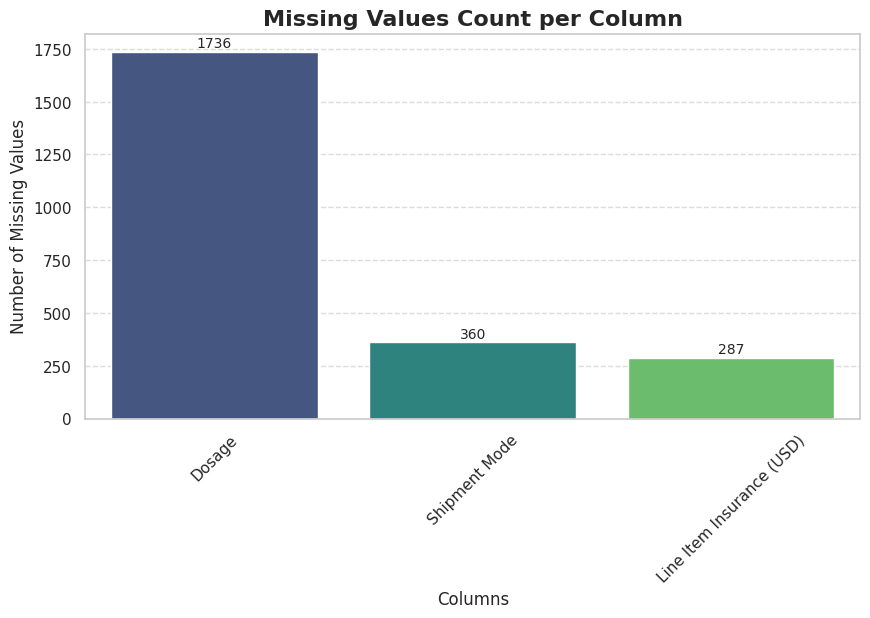

In [112]:
# Visualizing the missing values

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=missing.index, y=missing.values, hue=missing.index, palette='viridis', legend=False)

plt.title("Missing Values Count per Column", fontsize=16, fontweight='bold')
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Value labels
for i, v in enumerate(missing.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.show()


### **About the** **Datasets**

The bar chart shows the count of missing values across different columns. The 'Dosage' column contains the highest number of missing values, followed by 'Shipment Mode' and 'Line Item Insurance (USD)'. Overall, the dataset has relatively few missing values, indicating good data quality.

# **2. Understanding the Variables**

In [113]:
# Dataset Columns

df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [114]:
# Dataset Describe

df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


### Variables Description

The dataset consists of multiple features related to supply chain shipment operations. It includes both categorical and numerical variables.

Categorical variables include:
- Shipment Mode
- Country
- Vendor
- Product Group

Numerical variables include:
- Line Item Quantity
- Unit Price
- Freight Cost (USD)
- Weight (Kilograms)

These variables help in understanding shipment distribution, vendor performance, and cost analysis.

### Checking Unique Values for each variable.

In [115]:
# Unique Values for each variable.

df.nunique()

,0
ID,10324
Project Code,142
PQ #,1237
PO / SO #,6233
ASN/DN #,7030
Country,43
Managed By,4
Fulfill Via,2
Vendor INCO Term,8
Shipment Mode,4


# **3.** **Data Wrangling**

### Data Wrangling Code

In [116]:
# To make the dataset analysis ready.

df = df.drop_duplicates()
df.fillna(0, inplace=True)


### Manipulations and Insights found.

Data cleaning and preprocessing steps were performed to prepare the dataset for analysis. Duplicate records were removed to ensure data consistency. Missing values were handled by filling them appropriately to avoid errors during analysis.

The dataset was then explored to understand the structure and variables. Both categorical and numerical variables were identified, and unique values were analyzed.

The initial analysis revealed that the dataset is relatively clean with minimal missing values. Key variables such as shipment mode, vendor, and country play an important role in understanding logistics patterns. These preprocessing steps ensured that the dataset was ready for further exploratory data analysis and visualization.

## **4. Data Vizualization with charts**

# **Shipment Mode**

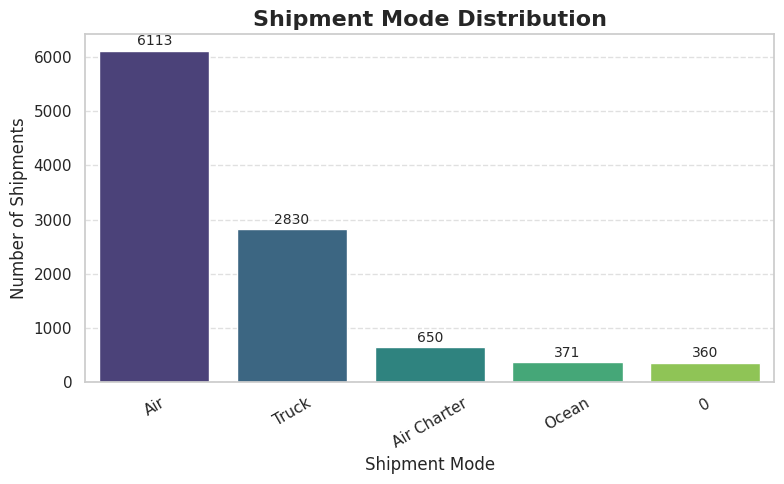

In [117]:
# Chart - 1 Shipment Mode

df['Shipment Mode'] = df['Shipment Mode'].replace('0', 'Unknown')

# Get counts
shipment_counts = df['Shipment Mode'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=shipment_counts.index,
    y=shipment_counts.values,
    hue=shipment_counts.index,
    palette='viridis',
    legend=False
)

plt.title("Shipment Mode Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels
for i, v in enumerate(shipment_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

A count plot is used to visualize the frequency distribution of categorical variables. Shipment Mode is a key categorical feature in the dataset, and this chart helps in understanding which transportation method is used the most. It provides a clear comparison of shipment modes.

The chart shows that air shipment is the most frequently used transportation mode compared to others. This indicates a preference for faster delivery methods in the supply chain. Other modes such as sea or land are used less frequently.

The insights can help create a positive business impact. Understanding that air shipment is the most used mode can help companies optimize logistics planning and cost management. However, heavy reliance on air transportation may increase operational costs. Businesses can explore alternative shipment modes to reduce costs while maintaining efficiency.

# **Top Countries**

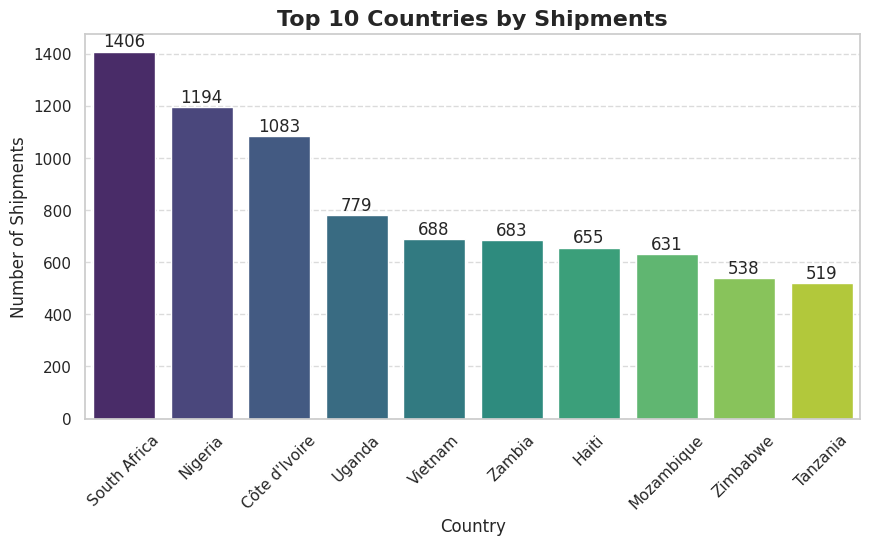

In [118]:
# Chart - 2 Top Countries

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values,
    hue=top_countries.index,
    palette='viridis',
    legend=False
)

plt.title("Top 10 Countries by Shipments", fontsize=16, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Number of Shipments")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Value labels
for i, v in enumerate(top_countries.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.show()


A bar chart is used to compare shipment volumes across different countries. Country is an important categorical variable in the dataset, and this chart helps identify which regions receive the highest number of shipments.

The chart shows that a few countries receive a significantly higher number of shipments compared to others. This indicates that shipment demand is concentrated in specific regions, highlighting key markets in the supply chain.

This insight helps in creating a positive business impact. By identifying countries with high shipment volumes, companies can focus on optimizing logistics, improving delivery efficiency, and strengthening supply chain operations in those regions. However, over-dependence on a few countries may create risk if demand fluctuates in those regions.

# **Vendor Analysis**

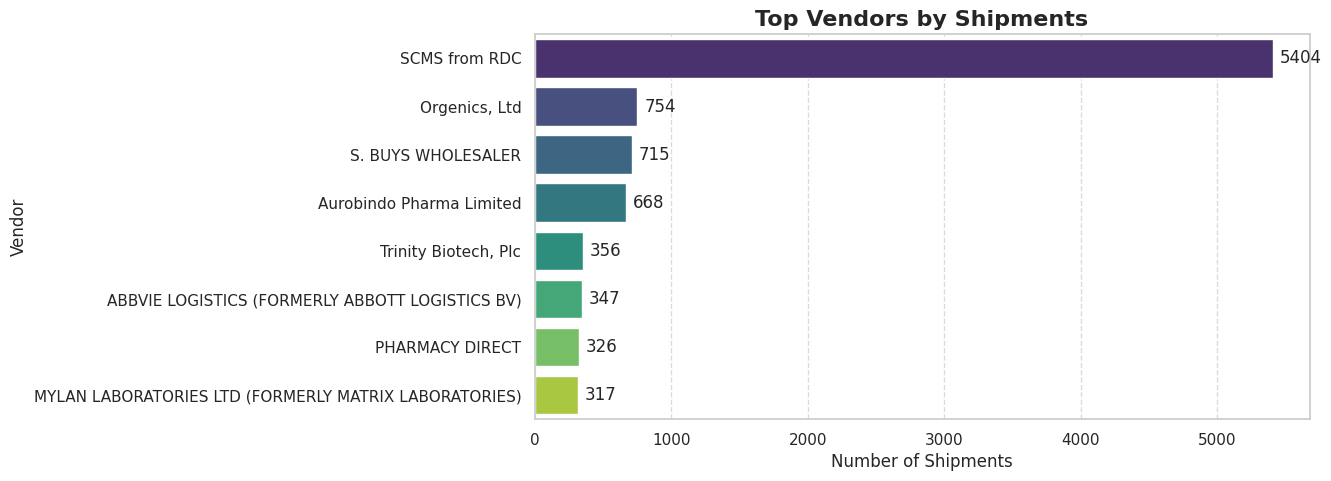

In [119]:
# Chart - 3 Vendor Analysis

top_vendors = df['Vendor'].value_counts().head(8)

plt.figure(figsize=(10,5))

sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    hue=top_vendors.index,
    palette='viridis',
    legend=False
)

plt.title("Top Vendors by Shipments", fontsize=16, fontweight='bold')
plt.xlabel("Number of Shipments")
plt.ylabel("Vendor")

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Value labels
for i, v in enumerate(top_vendors.values):
    plt.text(v + 50, i, str(v), va='center')

plt.show()

The chart shows that a few vendors handle a significantly higher number of shipments compared to others. One vendor dominates the distribution, indicating heavy dependency on specific suppliers within the supply chain.

The chart shows that a few vendors handle a significantly higher number of shipments compared to others. This indicates that the supply chain is highly dependent on a small number of vendors.

Also, this insight can create a positive business impact. Identifying top-performing vendors helps companies strengthen partnerships and improve supply chain efficiency. However, over-reliance on a few vendors can be risky, as any disruption from these vendors may affect the entire supply chain.Answer Here

# **Product Group**

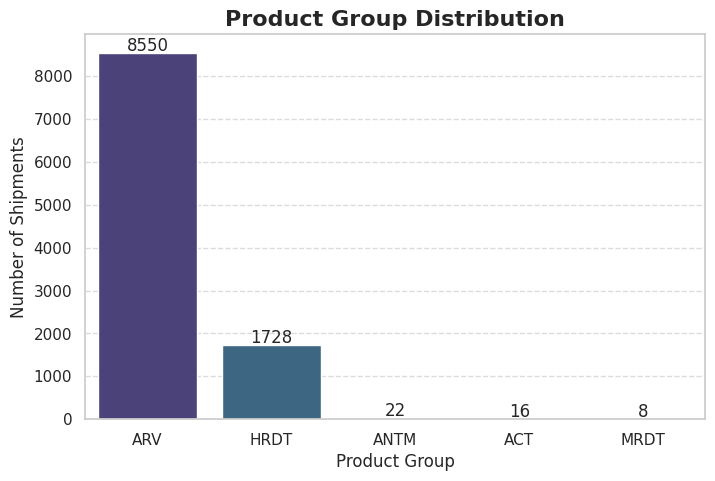

In [120]:
# Chart - 4 Product Group

top_products = df['Product Group'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.index,
    y=top_products.values,
    hue=top_products.index,
    palette='viridis',
    legend=False
)

plt.title("Product Group Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Product Group")
plt.ylabel("Number of Shipments")

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Value labels
for i, v in enumerate(top_products.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.show()

A bar chart is used to analyze the distribution of different product groups. It helps in identifying which product categories contribute the most to shipments.

The chart shows that one product group dominates the shipment distribution, while other product groups contribute significantly less. This indicates an uneven distribution across product categories.

This insight helps businesses focus on high-demand product groups for better inventory management and supply chain optimization. However, heavy dependence on one product category may increase business risk.

# **Shipment Mode vs Quantity**

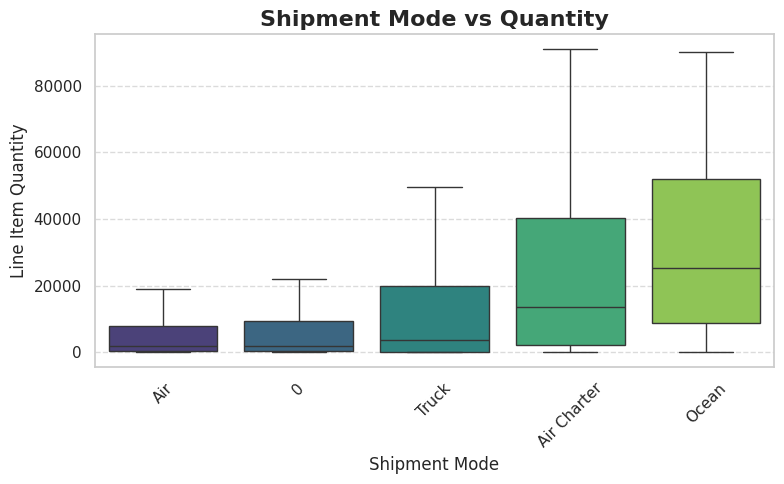

In [121]:
# Chart - 5 Shipment Mode vs Quantity

filtered_df = df[df['Line Item Quantity'] < df['Line Item Quantity'].quantile(0.95)]

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Shipment Mode',
    y='Line Item Quantity',
    data=filtered_df,
    hue='Shipment Mode',
    palette='viridis',
    showfliers=False,
    legend=False
)

plt.title("Shipment Mode vs Quantity", fontsize=16, fontweight='bold')
plt.xlabel("Shipment Mode")
plt.ylabel("Line Item Quantity")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

A boxplot is used to compare shipment quantity across different shipment modes. Outliers are removed to improve clarity and better understand the distribution.

The chart shows that shipment quantity varies significantly across shipment modes. Ocean and Air Charter shipments generally handle higher quantities compared to Air and Truck.

This insight helps in selecting appropriate shipment modes based on order size, improving logistics efficiency and reducing operational costs.

# **Quality Distribution**

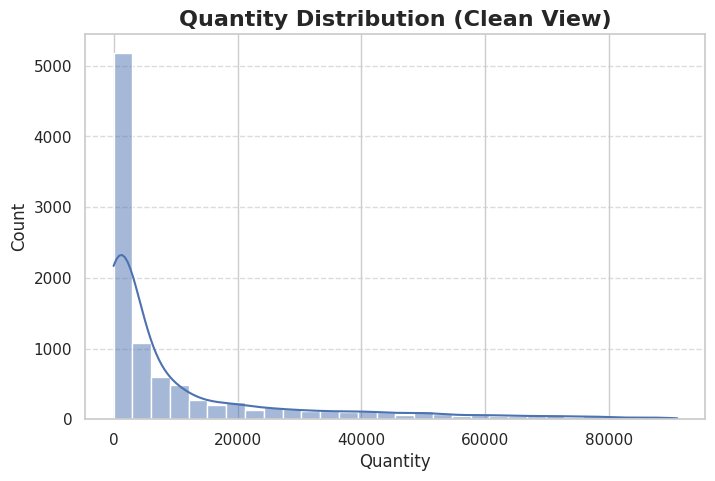

In [122]:
# Chart - 6 Quality Distribution

filtered = df[df['Line Item Quantity'] < df['Line Item Quantity'].quantile(0.95)]

plt.figure(figsize=(8,5))

sns.histplot(filtered['Line Item Quantity'], bins=30, kde=True)

plt.title("Quantity Distribution (Clean View)", fontsize=16, fontweight='bold')
plt.xlabel("Quantity")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

A histogram is used to understand the distribution of shipment quantities. A log scale is applied to handle skewness and improve visualization clarity.

The distribution is highly right-skewed, meaning most shipments have low to moderate quantities, while a few shipments have very high quantities.

This insight helps in planning logistics and storage efficiently, as most shipments are small while a few require high capacity handling.

# **Unit price distribution**

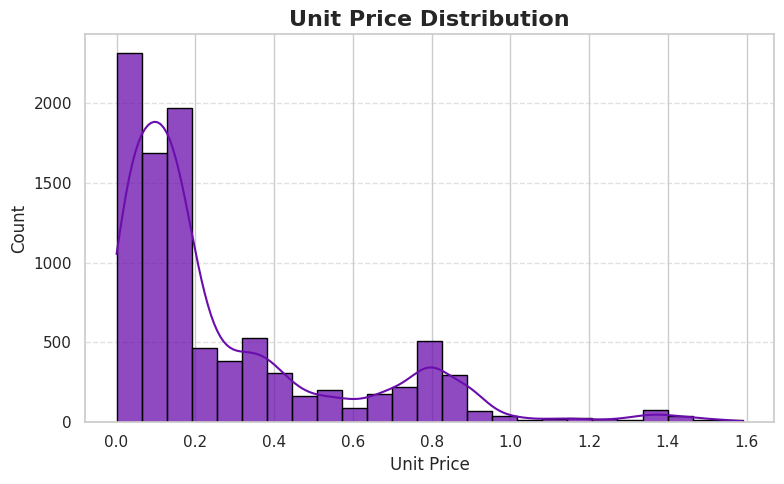

In [123]:
# Chart - 7 Unit price distribution

filtered = df[df['Unit Price'] < df['Unit Price'].quantile(0.95)]

plt.figure(figsize=(8,5))

sns.histplot(
    filtered['Unit Price'],
    bins=25,
    kde=True,
    color='#6A0DAD',
    edgecolor='black',
    alpha=0.75,
    linewidth=1
)

plt.title("Unit Price Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Unit Price")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

A histogram with KDE is used to analyze the distribution of unit prices. Outliers are removed to improve clarity and better understand the pricing pattern.

The distribution is right-skewed, indicating that most unit prices are concentrated in the lower range, while a few items have significantly higher prices.

This insight helps businesses focus on optimizing pricing strategies for high-volume low-cost products while identifying opportunities in higher-priced items to maximize revenue.

# **Weight Distribution**

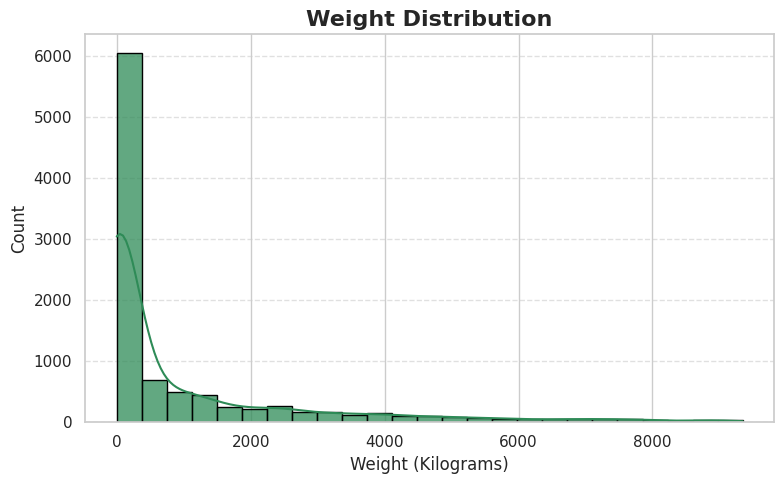

In [124]:
# Chart - 8 Weight Distribution


df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

df['Weight (Kilograms)'] = df['Weight (Kilograms)'].fillna(0)


filtered = df[df['Weight (Kilograms)'] < df['Weight (Kilograms)'].quantile(0.95)]

plt.figure(figsize=(8,5))

sns.histplot(
    filtered['Weight (Kilograms)'],
    bins=25,
    kde=True,
    color='#2E8B57',
    edgecolor='black',
    alpha=0.75
)

plt.title("Weight Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Weight (Kilograms)")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

A histogram with KDE is used to analyze the distribution of shipment weight. It helps in understanding how shipment weights are spread across different ranges.

The distribution is right-skewed, indicating that most shipments have lower to moderate weights, while only a few shipments are very heavy. This shows that bulk shipments are less frequent.

This insight helps in optimizing transportation and storage planning. Since most shipments are lightweight, logistics can be optimized for efficiency, while special handling can be arranged for heavy shipments.



# **Freight Cost Distribution**

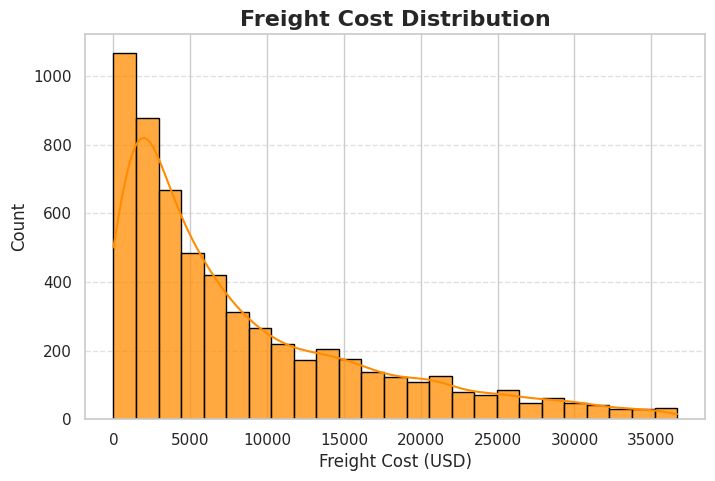

In [125]:
# Chart - 9 Freight Cost Distribution

df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

filtered = df[df['Freight Cost (USD)'] < df['Freight Cost (USD)'].quantile(0.95)]

plt.figure(figsize=(8,5))

sns.histplot(
    filtered['Freight Cost (USD)'],
    bins=25,
    kde=True,
    color='#FF8C00',
    edgecolor='black',
    alpha=0.75
)

plt.title("Freight Cost Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

A histogram with KDE is used to analyze the distribution of freight cost. It helps in understanding how transportation costs vary across shipments.

The distribution is right-skewed, indicating that most shipments have lower freight costs, while a few shipments incur very high costs. This shows that high-cost shipments are less frequent but significant.

This insight helps in managing logistics costs effectively. Businesses can focus on optimizing frequent low-cost shipments while identifying and controlling factors that lead to high-cost shipments.

# **Country vs Shipment**


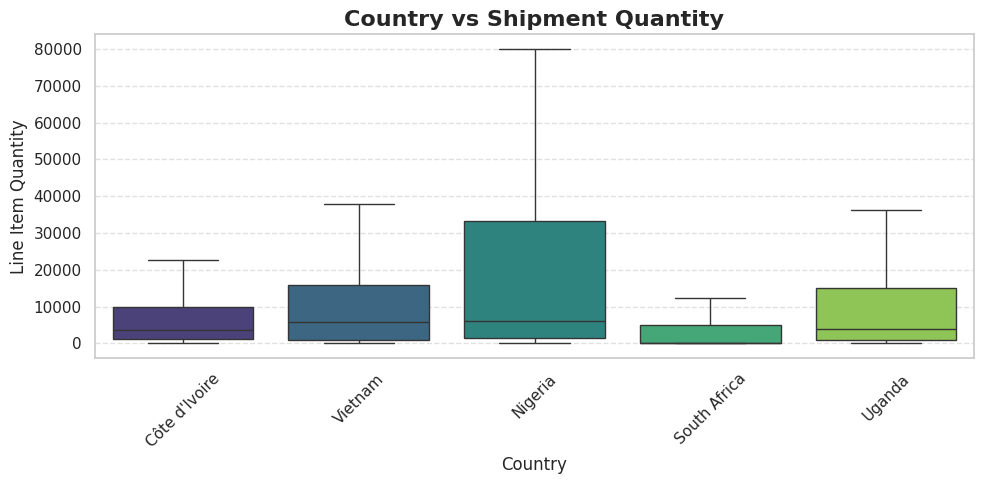

In [126]:
# Chart - 10 Country vs Shipment

top_countries = df['Country'].value_counts().head(5).index
filtered = df[df['Country'].isin(top_countries)]

plt.figure(figsize=(10,5))

sns.boxplot(
    x='Country',
    y='Line Item Quantity',
    data=filtered,
    hue='Country',
    palette='viridis',
    showfliers=False,
    legend=False
)

plt.title("Country vs Shipment Quantity", fontsize=16, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Line Item Quantity")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

A boxplot is used to compare shipment quantity across different countries. It helps in understanding the variation and distribution of shipment quantities in key regions.

The chart shows that shipment quantities vary across countries. Some countries have higher median shipment quantities, indicating higher demand or larger order sizes compared to others.

This insight helps businesses identify high-demand regions and optimize supply chain operations accordingly. It allows better allocation of resources and improved logistics planning for different countries.

# **Shipment Mode vs Freight Cost**

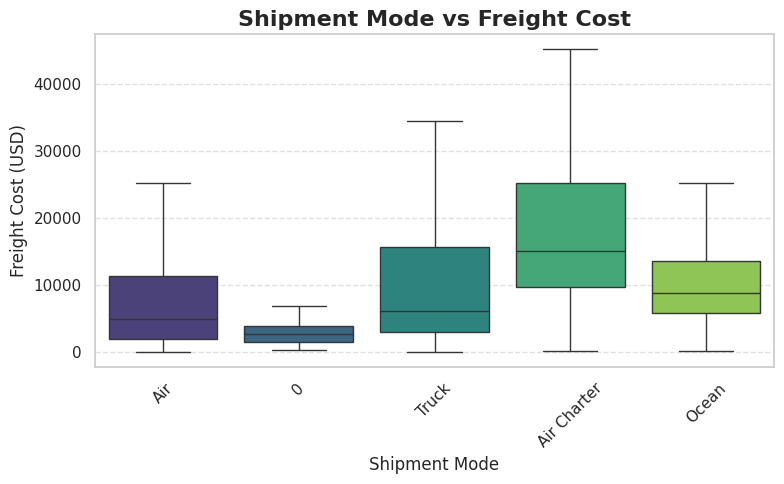

In [127]:
# Chart - 11 Shipment Mode vs Freight Cost

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Shipment Mode',
    y='Freight Cost (USD)',
    data=filtered,
    hue='Shipment Mode',
    palette='viridis',
    showfliers=False,
    dodge=False,
    legend=False
)

plt.title("Shipment Mode vs Freight Cost", fontsize=16, fontweight='bold')
plt.xlabel("Shipment Mode")
plt.ylabel("Freight Cost (USD)")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


A boxplot is used to compare freight cost across different shipment modes. It helps in understanding cost distribution and variation for each transportation method.

The chart shows that Air Charter shipments have the highest freight cost, while other shipment modes such as Air and Truck have relatively lower costs. This indicates that premium and urgent shipment methods are more expensive.

This insight helps businesses choose cost-effective shipment methods. While faster shipment options like Air Charter improve delivery speed, they significantly increase costs. Companies can balance cost and efficiency based on business needs.

#**Weight vs Freight Cost**

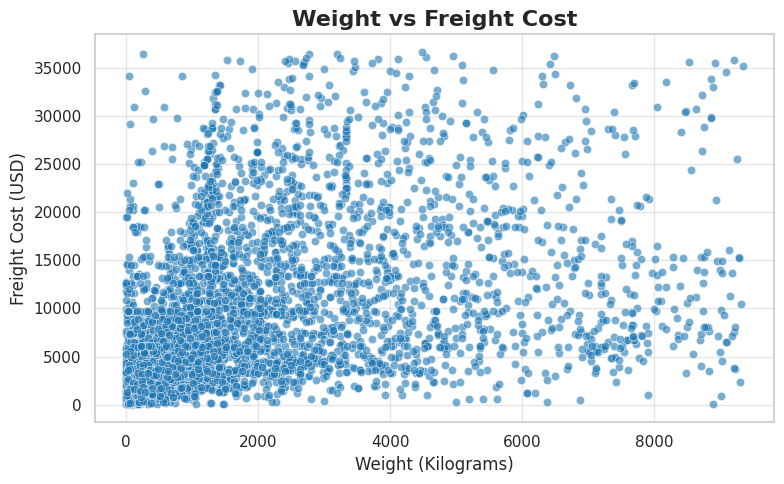

In [128]:
# Chart - 12 Weight vs Freight Cost

df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

filtered = df[
    (df['Weight (Kilograms)'] < df['Weight (Kilograms)'].quantile(0.95)) &
    (df['Freight Cost (USD)'] < df['Freight Cost (USD)'].quantile(0.95))
]

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Weight (Kilograms)',
    y='Freight Cost (USD)',
    data=filtered,
    alpha=0.6,
    color='#1f77b4'
)

plt.title("Weight vs Freight Cost", fontsize=16, fontweight='bold')
plt.xlabel("Weight (Kilograms)")
plt.ylabel("Freight Cost (USD)")

plt.grid(alpha=0.5)
plt.tight_layout()

plt.show()

A count plot is used to analyze the frequency of different shipment modes.

Some shipment modes are used more frequently than others, indicating preferred transportation methods.

This helps in understanding logistics preferences and optimizing transportation strategies.

#**Top Vendors by Average Freight Cost**

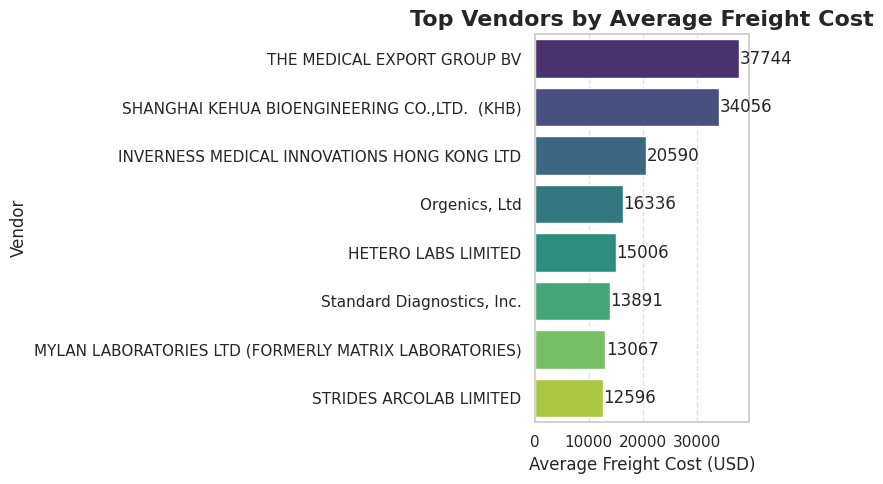

In [129]:
# Chart - 13 Top Vendors by Average Freight Cost

df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

# Calculate average cost per vendor
vendor_cost = df.groupby('Vendor')['Freight Cost (USD)'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(8,5))

sns.barplot(
    y=vendor_cost.index,
    x=vendor_cost.values,
    hue=vendor_cost.index,
    palette='viridis',
    legend=False
)

plt.title("Top Vendors by Average Freight Cost", fontsize=16, fontweight='bold')
plt.xlabel("Average Freight Cost (USD)")
plt.ylabel("Vendor")

plt.grid(axis='x', linestyle='--', alpha=0.6)

# Value labels
for i, v in enumerate(vendor_cost.values):
    plt.text(v + 100, i, f"{v:.0f}", va='center')

plt.tight_layout()
plt.show()

A bar chart is used to compare the average freight cost across different vendors. It helps in identifying cost differences among suppliers.

The chart shows that some vendors have significantly higher average freight costs compared to others, indicating variations in logistics efficiency or shipment types.

This insight helps businesses identify cost-efficient vendors and optimize supplier selection. It can reduce overall logistics expenses by choosing vendors with lower average costs.

# **Correlation Heatmap**

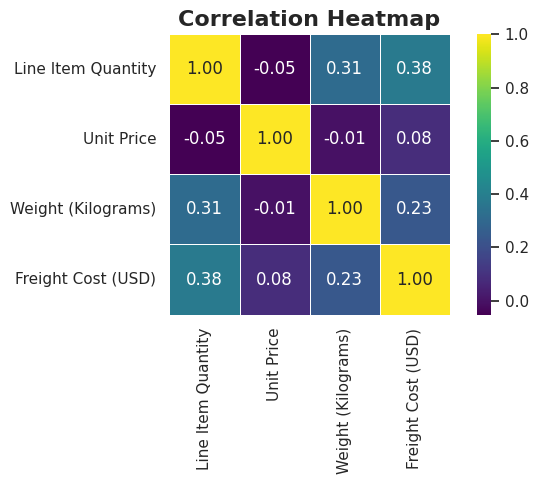

In [130]:
# Chart - 14 Correlation Heatmap

cols = ['Line Item Quantity', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)']

# Convert to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create correlation matrix
corr = df[cols].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

A correlation heatmap is used to understand the relationship between numerical variables. It helps identify how strongly different features are related.

The heatmap shows a positive correlation between freight cost, weight, and quantity. This indicates that heavier and larger shipments generally result in higher transportation costs.

This insight helps in predicting logistics costs and optimizing shipment planning. Businesses can manage shipment size and weight to control transportation expenses.

# **Pair Plot**

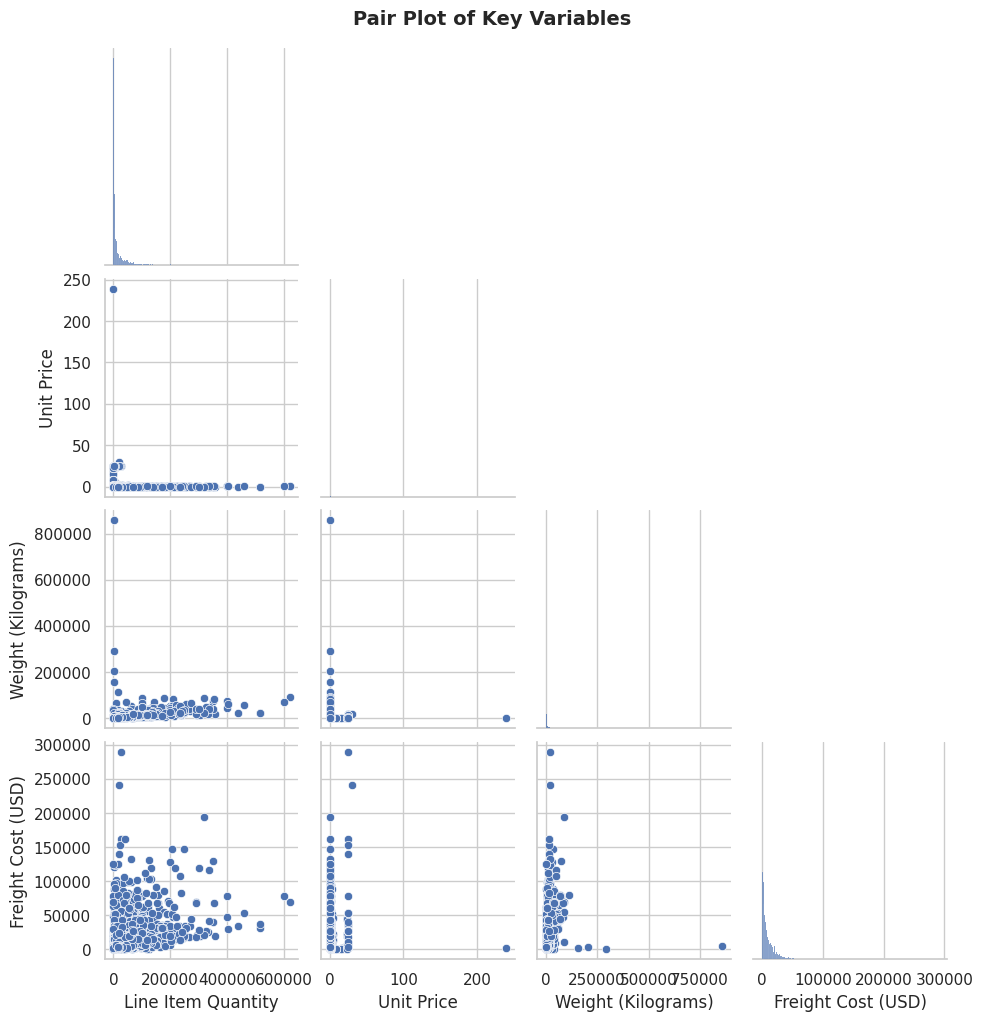

In [131]:
# Chart - 15 Pair Plot

cols = ['Line Item Quantity', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)']

# Convert to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values (important for pairplot)
pair_df = df[cols].dropna()

sns.pairplot(pair_df, corner=True)   # corner=True = cleaner view

plt.suptitle("Pair Plot of Key Variables", y=1.02, fontsize=14, fontweight='bold')

plt.show()

A pair plot is used to visualize relationships between multiple numerical variables simultaneously. It helps in understanding both individual distributions and pairwise relationships.

The pair plot shows that freight cost has a positive relationship with weight and quantity. It also highlights the distribution of each variable and shows that most variables are right-skewed.

## **5. Solution to Business Objective**

Based on the analysis, the client should focus on optimizing shipment strategies by selecting cost-effective shipment modes and vendors. Since freight cost increases with weight and quantity, proper planning of shipment size can reduce logistics expenses. Additionally, businesses should avoid over-dependence on specific vendors or regions and aim for diversification to reduce risk. Improving efficiency in frequently used shipment modes can also enhance overall supply chain performance.

# **Conclusion**

In this project, I have performed exploratory data analysis on the supply chain dataset to understand shipment patterns, cost distribution, and relationships between key variables. The analysis revealed that most shipments are small to moderate in size, while freight cost is positively influenced by weight and quantity. Certain shipment modes and vendors dominate operations, indicating areas for optimization. The visualizations helped uncover important trends and patterns, enabling better decision-making in logistics and supply chain management. Overall, this analysis provides valuable insights to improve efficiency, reduce costs, and enhance business performance.